## CycleGAN + DiffAugment + generator EMA

### Preparing Environment

In [ ]:
# ============================================================
# New CycleGAN experiment setup: DiffAugment + EMA
# ============================================================

import random
import logging
from pathlib import Path

import numpy as np
import torch


# ------------------------------------------------------------
# 1. Experiment name
# ------------------------------------------------------------

EXPERIMENT_NAME = "task3_gan_feature_matching_ema"


# ------------------------------------------------------------
# 2. Reproducibility
# ------------------------------------------------------------

SEED = 5775

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# 3. Select device
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


# ------------------------------------------------------------
# 4. Efficient CUDA settings
# ------------------------------------------------------------

if torch.cuda.is_available():
    # Faster when image dimensions remain fixed
    torch.backends.cudnn.benchmark = True

    # Improve matrix multiplication performance
    torch.set_float32_matmul_precision("high")

    # Allow TF32 where supported
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True


# ------------------------------------------------------------
# 5. Project paths
# ------------------------------------------------------------

WORKSPACE_ROOT = Path.cwd()

# Reuse the dataset from the original experiment
DATA_DIR = (
    WORKSPACE_ROOT
    / "task3_gan"
    / "data"
)

# Store all new experiment artifacts separately
PROJECT_ROOT = (
    WORKSPACE_ROOT
    / EXPERIMENT_NAME
)

CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
SAMPLE_DIR = PROJECT_ROOT / "samples"
RESULTS_DIR = PROJECT_ROOT / "results"
LOG_DIR = PROJECT_ROOT / "logs"

for folder in [
    PROJECT_ROOT,
    CHECKPOINT_DIR,
    SAMPLE_DIR,
    RESULTS_DIR,
    LOG_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )


# ------------------------------------------------------------
# 6. Verify the shared dataset
# ------------------------------------------------------------

DOMAIN_A_DIR = DATA_DIR / "photo_jpg"
DOMAIN_B_DIR = DATA_DIR / "monet_jpg"

if not DOMAIN_A_DIR.is_dir():
    raise FileNotFoundError(
        f"Photo folder not found: {DOMAIN_A_DIR}"
    )

if not DOMAIN_B_DIR.is_dir():
    raise FileNotFoundError(
        f"Monet folder not found: {DOMAIN_B_DIR}"
    )


# ------------------------------------------------------------
# 7. New experiment log
# ------------------------------------------------------------

LOG_FILE = LOG_DIR / "run_log.txt"

logger = logging.getLogger(
    "task3_cyclegan_feature_matching_ema"
)

logger.setLevel(logging.INFO)
logger.propagate = False

# Remove old handlers if this cell is executed again
for handler in logger.handlers[:]:
    handler.close()
    logger.removeHandler(handler)

file_handler = logging.FileHandler(
    LOG_FILE,
    mode="a",
)

console_handler = logging.StreamHandler()

formatter = logging.Formatter(
    "%(asctime)s - %(levelname)s - %(message)s"
)

file_handler.setFormatter(formatter)
console_handler.setFormatter(formatter)

logger.addHandler(file_handler)
logger.addHandler(console_handler)


# ------------------------------------------------------------
# 8. Log experiment information
# ------------------------------------------------------------

logger.info("Starting new CycleGAN experiment")
logger.info(f"Experiment: {EXPERIMENT_NAME}")
logger.info(f"Random seed: {SEED}")
logger.info(f"Device: {device}")
logger.info(f"Shared data directory: {DATA_DIR}")
logger.info(f"Experiment directory: {PROJECT_ROOT}")

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)

    gpu_memory_gb = (
        torch.cuda.get_device_properties(0).total_memory
        / (1024 ** 3)
    )

    logger.info(f"GPU: {gpu_name}")
    logger.info(
        f"GPU memory: {gpu_memory_gb:.2f} GB"
    )
else:
    logger.info(
        "CUDA is unavailable. Using CPU."
    )


# ------------------------------------------------------------
# 9. Display setup
# ------------------------------------------------------------

print("Setup completed successfully.")
print("Experiment:", EXPERIMENT_NAME)
print("Device:", device)
print("Shared dataset:", DATA_DIR)
print("New experiment folder:", PROJECT_ROOT)
print("Checkpoint folder:", CHECKPOINT_DIR)
print("Sample folder:", SAMPLE_DIR)
print("Results folder:", RESULTS_DIR)
print("Log file:", LOG_FILE)

2026-10-02 02:39:19,530 - INFO - Starting new CycleGAN experiment
2026-10-02 02:39:19,531 - INFO - Experiment: task3_gan_feature_matching_ema
2026-10-02 02:39:19,531 - INFO - Random seed: 5775
2026-10-02 02:39:19,532 - INFO - Device: cuda
2026-10-02 02:39:19,532 - INFO - Shared data directory: /app/task3_gan/data
2026-10-02 02:39:19,533 - INFO - Experiment directory: /app/task3_gan_feature_matching_ema
2026-10-02 02:39:19,559 - INFO - GPU: NVIDIA GeForce RTX 5090
2026-10-02 02:39:19,560 - INFO - GPU memory: 31.84 GB


Setup completed successfully.
Experiment: task3_gan_feature_matching_ema
Device: cuda
Shared dataset: /app/task3_gan/data
New experiment folder: /app/task3_gan_feature_matching_ema
Checkpoint folder: /app/task3_gan_feature_matching_ema/checkpoints
Sample folder: /app/task3_gan_feature_matching_ema/samples
Results folder: /app/task3_gan_feature_matching_ema/results
Log file: /app/task3_gan_feature_matching_ema/logs/run_log.txt


### Data Preparation

In [ ]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [ ]:
# Defining dataset settings
import os
IMAGE_SIZE = 256
RESIZE_SIZE = 286
BATCH_SIZE = 4
TRAIN_NUM_WORKERS = 2
VALIDATION_NUM_WORKERS = 0

# setting the domain paths
DOMAIN_A_DIR = DATA_DIR / "photo_jpg"
DOMAIN_B_DIR = DATA_DIR / "monet_jpg"

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}


In [ ]:
DOMAIN_A_DIR

PosixPath('/app/task3_gan/data/photo_jpg')

In [ ]:
DOMAIN_B_DIR

PosixPath('/app/task3_gan/data/monet_jpg')

In [ ]:
def find_images(folder):
    """Return all image paths inside a folder."""

    if not folder.exists():
        raise FileNotFoundError(f"Folder not found: {folder}")

    image_paths = [
        path
        for path in folder.rglob("*")
        if path.suffix.lower() in IMAGE_EXTENSIONS
    ]

    image_paths = sorted(image_paths)

    if len(image_paths) == 0:
        raise ValueError(f"No images found in: {folder}")

    return image_paths


**Train - Validation Split**

In [ ]:
# taking 10% for validation

VALIDATION_FRACTION = 0.10

In [ ]:
# splitting images paths

def split_image_paths(image_paths, validation_fraction, seed):
    paths = list(image_paths)

    random_generator = random.Random(seed)
    random_generator.shuffle(paths)

    validation_size = max(
        1,
        int(len(paths) * validation_fraction)
    )

    validation_paths = paths[:validation_size]
    training_paths = paths[validation_size:]

    return training_paths, validation_paths


all_a_paths = find_images(DOMAIN_A_DIR)
all_b_paths = find_images(DOMAIN_B_DIR)

print("Total photos:", len(all_a_paths))
print("Total Monet images:", len(all_b_paths))

assert len(all_a_paths) == 7038
assert len(all_b_paths) == 300

train_a_paths, val_a_paths = split_image_paths(
    all_a_paths,
    VALIDATION_FRACTION,
    SEED,
)

train_b_paths, val_b_paths = split_image_paths(
    all_b_paths,
    VALIDATION_FRACTION,
    SEED + 1,
)


Total photos: 7038
Total Monet images: 300


In [ ]:
## Image transformation
# resizing, cropping, horizontal flip and normalization

train_transform = transforms.Compose([
    transforms.Resize(
        RESIZE_SIZE,
        interpolation=transforms.InterpolationMode.BICUBIC
    ),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    ),
])

## applying validation transformation


validation_transform = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE),
        interpolation=transforms.InterpolationMode.BICUBIC,
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5),
    ),
])


In [ ]:
# Dataset class

class UnpairedPathDataset(Dataset):
    def __init__(
        self,
        domain_a_paths,
        domain_b_paths,
        transform,
        random_pairing=True,
    ):
        self.domain_a_images = domain_a_paths
        self.domain_b_images = domain_b_paths
        self.transform = transform
        self.random_pairing = random_pairing

    def __len__(self):
        return max(
            len(self.domain_a_images),
            len(self.domain_b_images),
        )

    def __getitem__(self, index):
        a_index = index % len(self.domain_a_images)

        if self.random_pairing:
            b_index = torch.randint(
                0,
                len(self.domain_b_images),
                size=(1,),
            ).item()
        else:
            b_index = index % len(self.domain_b_images)

        a_path = self.domain_a_images[a_index]
        b_path = self.domain_b_images[b_index]

        image_a = Image.open(a_path).convert("RGB")
        image_b = Image.open(b_path).convert("RGB")

        image_a = self.transform(image_a)
        image_b = self.transform(image_b)

        return {
            "A": image_a,
            "B": image_b,
            "A_path": str(a_path),
            "B_path": str(b_path),
        }


In [ ]:
## creating train and validation dataset

train_dataset = UnpairedPathDataset(
    domain_a_paths=all_a_paths,
    domain_b_paths=all_b_paths,
    transform=train_transform,
    random_pairing=True,
)

validation_dataset = UnpairedPathDataset(
    domain_a_paths=val_a_paths,
    domain_b_paths=val_b_paths,
    transform=validation_transform,
    random_pairing=False,
)

In [ ]:
## creating data loader

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=TRAIN_NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(TRAIN_NUM_WORKERS > 0),
    prefetch_factor=1,
    drop_last=False,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=VALIDATION_NUM_WORKERS,
    pin_memory=True,
    persistent_workers=False,
    drop_last=False,
)

##saving one fixed validation batch

fixed_validation_batch = next(iter(validation_loader))



logger.info(
    f"Full training photos: "
    f"{len(train_dataset.domain_a_images)}"
)

logger.info(
    f"Full training Monet images: "
    f"{len(train_dataset.domain_b_images)}"
)

logger.info(
    f"Monitoring photos: {len(val_a_paths)}"
)

logger.info(
    f"Monitoring Monet images: {len(val_b_paths)}"
)

print(
    "Full training photos:",
    len(train_dataset.domain_a_images),
)

print(
    "Full training Monet images:",
    len(train_dataset.domain_b_images),
)

print(
    "Monitoring photos:",
    len(val_a_paths),
)

print(
    "Monitoring Monet images:",
    len(val_b_paths),
)

print(
    "Training batches per epoch:",
    len(train_loader),
)

print(
    "Monitoring batches:",
    len(validation_loader),
)

sample_batch = next(iter(train_loader))
fixed_validation_batch = next(iter(validation_loader))

2026-10-02 02:39:20,718 - INFO - Full training photos: 7038
2026-10-02 02:39:20,721 - INFO - Full training Monet images: 300
2026-10-02 02:39:20,722 - INFO - Monitoring photos: 703
2026-10-02 02:39:20,723 - INFO - Monitoring Monet images: 30


Full training photos: 7038
Full training Monet images: 300
Monitoring photos: 703
Monitoring Monet images: 30
Training batches per epoch: 1760
Monitoring batches: 176


In [ ]:
## Verifying dataset


logger.info(
    f"Domain A images: {len(train_dataset.domain_a_images)}"
)
logger.info(
    f"Domain B images: {len(train_dataset.domain_b_images)}"
)
logger.info(f"Training batches: {len(train_loader)}")

sample_batch = next(iter(train_loader))

logger.info(
    f"Domain A batch shape: {sample_batch['A'].shape}"
)
logger.info(
    f"Domain B batch shape: {sample_batch['B'].shape}"
)

print("Dataset loaded successfully.")
print("Domain A shape:", sample_batch["A"].shape)
print("Domain B shape:", sample_batch["B"].shape)

2026-10-02 02:39:20,935 - INFO - Domain A images: 7038
2026-10-02 02:39:20,938 - INFO - Domain B images: 300
2026-10-02 02:39:20,938 - INFO - Training batches: 1760
2026-10-02 02:39:20,996 - INFO - Domain A batch shape: torch.Size([4, 3, 256, 256])
2026-10-02 02:39:20,997 - INFO - Domain B batch shape: torch.Size([4, 3, 256, 256])


Dataset loaded successfully.
Domain A shape: torch.Size([4, 3, 256, 256])
Domain B shape: torch.Size([4, 3, 256, 256])


### Building Generators

Domain A - Photo

Domain B - Monet

Generator_AB - photo to Monet

Generator_BA - Monet to Photo


Each generator has three main parts:
1. Downsampling: Compresses the image and learns important features.
2. Residual blocks: Change the image style while preserving its content.
3. Upsampling: Reconstructs the translated image at its original size.

using tanh for final activation function - values ranges from -1 to 1

residual blocks - 9

In [ ]:
import torch.nn as nn

In [ ]:
## Residual block

class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, kernel_size=3),
            nn.InstanceNorm2d(channels),
            nn.ReLU(inplace=True),

            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, kernel_size=3),
            nn.InstanceNorm2d(channels),
        )

    def forward(self, x):
        # Skip connection helps preserve image content
        return x + self.block(x)

In [ ]:
## Generator

class Generator(nn.Module):
    def __init__(
        self,
        input_channels=3,
        output_channels=3,
        num_residual_blocks=9,
    ):
        super().__init__()

        layers = [
            # Initial convolution
            nn.ReflectionPad2d(3),
            nn.Conv2d(
                input_channels,
                64,
                kernel_size=7
            ),
            nn.InstanceNorm2d(64),
            nn.ReLU(inplace=True),
        ]

        # Downsampling: 256 -> 128 -> 64
        channels = 64

        for _ in range(2):
            layers.extend([
                nn.Conv2d(
                    channels,
                    channels * 2,
                    kernel_size=4,
                    stride=2,
                    padding=1,
                ),
                nn.InstanceNorm2d(channels * 2),
                nn.ReLU(inplace=True),
            ])

            channels *= 2

        # Residual blocks
        for _ in range(num_residual_blocks):
            layers.append(ResidualBlock(channels))

        # Upsampling: 64 -> 128 -> 256
        for _ in range(2):
            layers.extend([
                nn.ConvTranspose2d(
                    channels,
                    channels // 2,
                    kernel_size=4,
                    stride=2,
                    padding=1,
                ),
                nn.InstanceNorm2d(channels // 2),
                nn.ReLU(inplace=True),
            ])

            channels //= 2

        # Output layer
        layers.extend([
            nn.ReflectionPad2d(3),
            nn.Conv2d(
                channels,
                output_channels,
                kernel_size=7
            ),
            nn.Tanh(),
        ])

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


In [ ]:
# Creating generators for both domains

G_AB = Generator().to(device)
G_BA = Generator().to(device)

In [ ]:
## counting trainable parameters

def count_parameters(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


logger.info(
    f"G_AB parameters: {count_parameters(G_AB):,}"
)
logger.info(
    f"G_BA parameters: {count_parameters(G_BA):,}"
)


2026-10-02 02:39:21,237 - INFO - G_AB parameters: 11,951,619
2026-10-02 02:39:21,238 - INFO - G_BA parameters: 11,951,619


In [ ]:
## Verifying generator output shape

test_image_a = sample_batch["A"][:1].to(device)

with torch.no_grad():
    test_fake_b = G_AB(test_image_a)

print("Generator input shape: ", test_image_a.shape)
print("Generator output shape:", test_fake_b.shape)

logger.info(
    f"Generator input shape: {test_image_a.shape}"
)
logger.info(
    f"Generator output shape: {test_fake_b.shape}"
)

2026-10-02 02:39:21,868 - INFO - Generator input shape: torch.Size([1, 3, 256, 256])
2026-10-02 02:39:21,869 - INFO - Generator output shape: torch.Size([1, 3, 256, 256])


Generator input shape:  torch.Size([1, 3, 256, 256])
Generator output shape: torch.Size([1, 3, 256, 256])


Input and Output dimensions are same.

Cycle GAN changes style so image size should remain same.

### Building Discriminators

decides whether an image is real or generated

Discriminator A - check photographs

Discriminator B - Monet paintings

Using PatchGAN discriminator - Instead of giving one score for the entire image, it produces a grid of scores. Each score evaluates a small region of the image.

This is useful because painting style mainly appears in local details such as:
- Texture
- Color patterns
- Edges
- Brush strokes

In [ ]:
## PatchGAN discriminator

class Discriminator(nn.Module):
    def __init__(self, input_channels=3):
        super().__init__()

        self.block_1 = nn.Sequential(
            nn.Conv2d(
                input_channels,
                64,
                kernel_size=4,
                stride=2,
                padding=1,
            ),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.block_2 = nn.Sequential(
            nn.Conv2d(
                64,
                128,
                kernel_size=4,
                stride=2,
                padding=1,
            ),
            nn.InstanceNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.block_3 = nn.Sequential(
            nn.Conv2d(
                128,
                256,
                kernel_size=4,
                stride=2,
                padding=1,
            ),
            nn.InstanceNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.block_4 = nn.Sequential(
            nn.Conv2d(
                256,
                512,
                kernel_size=4,
                stride=1,
                padding=1,
            ),
            nn.InstanceNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.output_layer = nn.Conv2d(
            512,
            1,
            kernel_size=4,
            stride=1,
            padding=1,
        )

    def forward(
        self,
        x,
        return_features=False,
    ):
        features = []

        x = self.block_1(x)
        features.append(x)

        x = self.block_2(x)
        features.append(x)

        x = self.block_3(x)
        features.append(x)

        x = self.block_4(x)
        features.append(x)

        prediction = self.output_layer(x)

        if return_features:
            return prediction, features

        return prediction

In [ ]:
# creating both discriminators

D_A = Discriminator().to(device)
D_B = Discriminator().to(device)

In [ ]:
# Logging parameter counts

logger.info(
    f"D_A parameters: {count_parameters(D_A):,}"
)
logger.info(
    f"D_B parameters: {count_parameters(D_B):,}"
)


2026-10-02 02:39:21,920 - INFO - D_A parameters: 2,764,737
2026-10-02 02:39:21,922 - INFO - D_B parameters: 2,764,737


In [ ]:
# Verifying discriminator output shapes

test_image_b = sample_batch["B"][:1].to(device)

with torch.no_grad():
    test_prediction_a = D_A(test_image_a)
    test_prediction_b = D_B(test_image_b)

print("D_A output shape:", test_prediction_a.shape)
print("D_B output shape:", test_prediction_b.shape)

logger.info(
    f"D_A output shape: {test_prediction_a.shape}"
)
logger.info(
    f"D_B output shape: {test_prediction_b.shape}"
)

2026-10-02 02:39:22,021 - INFO - D_A output shape: torch.Size([1, 1, 30, 30])
2026-10-02 02:39:22,022 - INFO - D_B output shape: torch.Size([1, 1, 30, 30])


D_A output shape: torch.Size([1, 1, 30, 30])
D_B output shape: torch.Size([1, 1, 30, 30])


### Setting up Losses and Optimizers

CycleGAN uses three types of loss:
- Adversarial loss: Makes translated images look real.
- Cycle-consistency loss: Ensures an image can be translated and reconstructed.
- Identity loss: Prevents unnecessary changes to colors and content.

- MSE loss for adversarial training, called Least-Squares GAN loss
- L1 loss for cycle and identity comparisons
- Adam optimizer with the standard CycleGAN learning rate
- Normal weight initialization for stable training

In [ ]:
from itertools import chain

In [ ]:
## training hyperparameters

LEARNING_RATE = 0.0002


LAMBDA_CYCLE = 7.5
LAMBDA_IDENTITY = 1.0
LAMBDA_FEATURE_MATCHING = 10.0

EMA_DECAY = 0.999
DIFFAUGMENT_POLICY = "translation,cutout"

CHECKPOINT_EVERY = 1
SNAPSHOT_EVERY = 5

ADAM_BETA1 = 0.5
ADAM_BETA2 = 0.999


In [ ]:
def initialize_weights(module):
    """Initialize convolution weights for stable GAN training."""

    if isinstance(module, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(module.weight, mean=0.0, std=0.02)

        if module.bias is not None:
            nn.init.zeros_(module.bias)

In [ ]:
## Initializing model weights

G_AB.apply(initialize_weights)
G_BA.apply(initialize_weights)
D_A.apply(initialize_weights)
D_B.apply(initialize_weights)

logger.info("Model weights initialized.")

2026-10-02 02:39:22,063 - INFO - Model weights initialized.


In [ ]:
import copy


# ------------------------------------------------------------
# Create EMA generators
# ------------------------------------------------------------

G_AB_ema = copy.deepcopy(G_AB).to(device)
G_BA_ema = copy.deepcopy(G_BA).to(device)

G_AB_ema.eval()
G_BA_ema.eval()

# EMA models are not trained using gradients
for parameter in G_AB_ema.parameters():
    parameter.requires_grad_(False)

for parameter in G_BA_ema.parameters():
    parameter.requires_grad_(False)


# ------------------------------------------------------------
# EMA update function
# ------------------------------------------------------------

@torch.no_grad()
def update_ema(ema_model, current_model, decay):
    for ema_parameter, current_parameter in zip(
        ema_model.parameters(),
        current_model.parameters(),
    ):
        ema_parameter.mul_(decay).add_(
            current_parameter.detach(),
            alpha=1.0 - decay,
        )

    # Copy model buffers, if any
    for ema_buffer, current_buffer in zip(
        ema_model.buffers(),
        current_model.buffers(),
    ):
        ema_buffer.copy_(current_buffer)

In [ ]:
## Defining loss functions

adversarial_loss = nn.MSELoss()
cycle_loss = nn.L1Loss()
identity_loss = nn.L1Loss()

In [ ]:
### Defining generator optimizer

optimizer_G = torch.optim.Adam(
    chain(G_AB.parameters(), G_BA.parameters()),
    lr=LEARNING_RATE,
    betas=(ADAM_BETA1, ADAM_BETA2),
)


In [ ]:
### Defining discriminator optimizer

optimizer_D = torch.optim.Adam(
    chain(D_A.parameters(), D_B.parameters()),
    lr=LEARNING_RATE,
    betas=(ADAM_BETA1, ADAM_BETA2),
)

optimizer_G updates both generators together.
optimizer_D updates both discriminators together.

In [ ]:

# training setting

total_parameters = (
    count_parameters(G_AB)
    + count_parameters(G_BA)
    + count_parameters(D_A)
    + count_parameters(D_B)
)

logger.info(f"Learning rate: {LEARNING_RATE}")
logger.info(f"Cycle loss weight: {LAMBDA_CYCLE}")
logger.info(f"Identity loss weight: {LAMBDA_IDENTITY}")
logger.info(
    f"Feature-matching loss weight: "
    f"{LAMBDA_FEATURE_MATCHING}"
)
logger.info(f"Total trainable parameters: {total_parameters:,}")

print("Loss functions and optimizers created successfully.")
print(f"Total trainable parameters: {total_parameters:,}")

2026-10-02 02:39:22,103 - INFO - Learning rate: 0.0002
2026-10-02 02:39:22,104 - INFO - Cycle loss weight: 7.5
2026-10-02 02:39:22,104 - INFO - Identity loss weight: 1.0
2026-10-02 02:39:22,105 - INFO - Feature-matching loss weight: 10.0
2026-10-02 02:39:22,105 - INFO - Total trainable parameters: 29,432,712


Loss functions and optimizers created successfully.
Total trainable parameters: 29,432,712


### Adding Image replay buffer

GAN training can become unstable if the discriminator only sees the newest generated images.
A replay buffer stores some previously generated images. During discriminator training, it returns either:
- A newly generated image, or
- An older generated image from the buffer
This gives the discriminator more variety and improves training stability. We need one buffer for each translation direction.

In [ ]:
# generated replay image buffer

class ImageReplayBuffer:
    def __init__(self, max_size=50):
        self.max_size = max_size
        self.images = []

    def push_and_pop(self, batch):
        returned_images = []

        for image in batch.detach():
            # Add batch dimension back
            image = image.unsqueeze(0)

            # Fill the buffer first
            if len(self.images) < self.max_size:
                self.images.append(image)
                returned_images.append(image)

            else:
                # Half the time, return an older image
                if random.random() > 0.5:
                    random_index = random.randint(
                        0,
                        self.max_size - 1
                    )

                    old_image = self.images[random_index].clone()
                    self.images[random_index] = image

                    returned_images.append(old_image)

                # Otherwise, return the current image
                else:
                    returned_images.append(image)

        return torch.cat(returned_images, dim=0)


In [ ]:

# One buffer for fake photographs
fake_a_buffer = ImageReplayBuffer(max_size=50)

# One buffer for fake Monet paintings
fake_b_buffer = ImageReplayBuffer(max_size=50)

logger.info("Image replay buffers created with size 50.")

print("Image replay buffers created successfully.")

2026-10-02 02:39:22,115 - INFO - Image replay buffers created with size 50.


Image replay buffers created successfully.


The buffer uses batch.detach() because discriminator training must not update the generators.

### Creating one training step

In [ ]:
import math

## mixed precision settings

USE_AMP = device.type == "cuda"
AMP_DTYPE = torch.bfloat16

# Gradient scaling is unnecessary with BF16
scaler_G = torch.amp.GradScaler(
    "cuda",
    enabled=False,
)

scaler_D = torch.amp.GradScaler(
    "cuda",
    enabled=False,
)

## helper functions

def set_requires_grad(models, requires_grad):
    """Enable or disable gradient calculation."""

    for model in models:
        for parameter in model.parameters():
            parameter.requires_grad = requires_grad


def calculate_gradient_norm(models):
    parameters = [
        parameter
        for model in models
        for parameter in model.parameters()
        if parameter.grad is not None
    ]

    total_norm = torch.nn.utils.clip_grad_norm_(
        parameters,
        max_norm=float("inf"),
    )

    return total_norm.item()

In [ ]:
# ============================================================
# Differentiable augmentation
# ============================================================

import torch.nn.functional as F


DIFFAUGMENT_POLICY = "translation,cutout"

TRANSLATION_RATIO = 0.125
CUTOUT_RATIO = 0.50


# ------------------------------------------------------------
# Random translation
# ------------------------------------------------------------

def random_translation(images, ratio=0.125):
    batch_size, channels, height, width = (
        images.shape
    )

    maximum_y_shift = int(
        height * ratio + 0.5
    )

    maximum_x_shift = int(
        width * ratio + 0.5
    )

    translation_y = torch.randint(
        low=-maximum_y_shift,
        high=maximum_y_shift + 1,
        size=(batch_size, 1, 1),
        device=images.device,
    )

    translation_x = torch.randint(
        low=-maximum_x_shift,
        high=maximum_x_shift + 1,
        size=(batch_size, 1, 1),
        device=images.device,
    )

    batch_grid, y_grid, x_grid = torch.meshgrid(
        torch.arange(
            batch_size,
            device=images.device,
        ),
        torch.arange(
            height,
            device=images.device,
        ),
        torch.arange(
            width,
            device=images.device,
        ),
        indexing="ij",
    )

    y_grid = torch.clamp(
        y_grid + translation_y + 1,
        min=0,
        max=height + 1,
    )

    x_grid = torch.clamp(
        x_grid + translation_x + 1,
        min=0,
        max=width + 1,
    )

    padded_images = F.pad(
        images,
        pad=(1, 1, 1, 1),
    )

    translated_images = (
        padded_images
        .permute(0, 2, 3, 1)
        [batch_grid, y_grid, x_grid]
        .permute(0, 3, 1, 2)
    )

    return translated_images.contiguous()


# ------------------------------------------------------------
# Random cutout
# ------------------------------------------------------------

def random_cutout(images, ratio=0.50):
    batch_size, channels, height, width = (
        images.shape
    )

    cutout_height = int(
        height * ratio + 0.5
    )

    cutout_width = int(
        width * ratio + 0.5
    )

    offset_y = torch.randint(
        low=0,
        high=height,
        size=(batch_size, 1, 1),
        device=images.device,
    )

    offset_x = torch.randint(
        low=0,
        high=width,
        size=(batch_size, 1, 1),
        device=images.device,
    )

    batch_grid, y_grid, x_grid = torch.meshgrid(
        torch.arange(
            batch_size,
            device=images.device,
        ),
        torch.arange(
            cutout_height,
            device=images.device,
        ),
        torch.arange(
            cutout_width,
            device=images.device,
        ),
        indexing="ij",
    )

    y_grid = torch.clamp(
        y_grid
        + offset_y
        - cutout_height // 2,
        min=0,
        max=height - 1,
    )

    x_grid = torch.clamp(
        x_grid
        + offset_x
        - cutout_width // 2,
        min=0,
        max=width - 1,
    )

    mask = torch.ones(
        batch_size,
        height,
        width,
        device=images.device,
        dtype=images.dtype,
    )

    mask[
        batch_grid,
        y_grid,
        x_grid,
    ] = 0

    return images * mask.unsqueeze(1)


# ------------------------------------------------------------
# Apply the selected augmentation policy
# ------------------------------------------------------------

def diff_augment(
    images,
    policy=DIFFAUGMENT_POLICY,
):
    if not policy:
        return images

    augmented_images = images

    for augmentation_name in policy.split(","):
        augmentation_name = (
            augmentation_name.strip()
        )

        if augmentation_name == "translation":
            augmented_images = random_translation(
                augmented_images,
                ratio=TRANSLATION_RATIO,
            )

        elif augmentation_name == "cutout":
            augmented_images = random_cutout(
                augmented_images,
                ratio=CUTOUT_RATIO,
            )

        else:
            raise ValueError(
                "Unknown DiffAugment operation: "
                f"{augmentation_name}"
            )

    return augmented_images.contiguous()

In [ ]:
test_images = sample_batch["A"].to(device)

augmented_test_images = diff_augment(
    test_images
)

assert augmented_test_images.shape == test_images.shape
assert torch.isfinite(augmented_test_images).all()

print("Original shape:", test_images.shape)
print("Augmented shape:", augmented_test_images.shape)
print("DiffAugment test passed.")

Original shape: torch.Size([4, 3, 256, 256])
Augmented shape: torch.Size([4, 3, 256, 256])
DiffAugment test passed.


In [ ]:
def calculate_feature_matching_loss(
    real_features,
    fake_features,
):
    total_loss = 0.0

    for real_feature, fake_feature in zip(
        real_features,
        fake_features,
    ):
        # Average across batch and spatial dimensions.
        real_statistics = real_feature.detach().mean(
            dim=(0, 2, 3)
        )

        fake_statistics = fake_feature.mean(
            dim=(0, 2, 3)
        )

        total_loss = total_loss + F.l1_loss(
            fake_statistics,
            real_statistics,
        )

    return total_loss / len(real_features)

In [ ]:
# ============================================================
# One CycleGAN training step with DiffAugment
# ============================================================

def train_step(batch):
    real_A = batch["A"].to(
        device,
        non_blocking=True,
    )

    real_B = batch["B"].to(
        device,
        non_blocking=True,
    )

    # ========================================================
    # 1. Train generators
    # ========================================================

    set_requires_grad([D_A, D_B], False)

    optimizer_G.zero_grad(
        set_to_none=True
    )

    with torch.autocast(
        device_type=device.type,
        dtype=AMP_DTYPE,
        enabled=USE_AMP,
    ):
        # ----------------------------------------------------
        # Translate images
        # ----------------------------------------------------

        fake_B = G_AB(real_A)
        fake_A = G_BA(real_B)

        # ----------------------------------------------------
        # Adversarial predictions with DiffAugment
        # ----------------------------------------------------

        augmented_fake_B = diff_augment(
            fake_B
        )

        augmented_fake_A = diff_augment(
            fake_A
        )

        prediction_fake_B = D_B(
            augmented_fake_B
        )

        prediction_fake_A, fake_photo_features = D_A(
    augmented_fake_A,
    return_features=True,
)

        loss_GAN_AB = adversarial_loss(
            prediction_fake_B,
            torch.ones_like(
                prediction_fake_B
            ),
        )

        loss_GAN_BA = adversarial_loss(
            prediction_fake_A,
            torch.ones_like(
                prediction_fake_A
            ),
        )

        # ----------------------------------------------------
        # Photo-domain feature matching
        # ----------------------------------------------------

        augmented_real_A_for_matching = diff_augment(
            real_A
        )

        _, real_photo_features = D_A(
            augmented_real_A_for_matching,
            return_features=True,
        )

        loss_feature_matching = (
            calculate_feature_matching_loss(
                real_features=real_photo_features,
                fake_features=fake_photo_features,
            )
        )
                # ----------------------------------------------------
        # Cycle reconstruction without DiffAugment
        # ----------------------------------------------------

        reconstructed_A = G_BA(fake_B)
        reconstructed_B = G_AB(fake_A)

        loss_cycle_A = cycle_loss(
            reconstructed_A,
            real_A,
        )

        loss_cycle_B = cycle_loss(
            reconstructed_B,
            real_B,
        )

        # ----------------------------------------------------
        # Identity mapping without DiffAugment
        # ----------------------------------------------------

        identity_A = G_BA(real_A)
        identity_B = G_AB(real_B)

        loss_identity_A = identity_loss(
            identity_A,
            real_A,
        )

        loss_identity_B = identity_loss(
            identity_B,
            real_B,
        )

        # ----------------------------------------------------
        # Combined generator loss
        # ----------------------------------------------------

        loss_G = (
    loss_GAN_AB
    + loss_GAN_BA
    + LAMBDA_CYCLE
    * (
        loss_cycle_A
        + loss_cycle_B
    )
    + LAMBDA_IDENTITY
    * (
        loss_identity_A
        + loss_identity_B
    )
    + LAMBDA_FEATURE_MATCHING
    * loss_feature_matching
)

    scaler_G.scale(loss_G).backward()

    scaler_G.unscale_(optimizer_G)

    gradient_norm_G = (
        calculate_gradient_norm(
            [G_AB, G_BA]
        )
    )

    scaler_G.step(optimizer_G)
    scaler_G.update()

    update_ema(
    G_AB_ema,
    G_AB,
    EMA_DECAY,
)

    update_ema(
        G_BA_ema,
        G_BA,
        EMA_DECAY,
    )

    # ========================================================
    # 2. Train discriminators
    # ========================================================

    set_requires_grad([D_A, D_B], True)

    optimizer_D.zero_grad(
        set_to_none=True
    )

    # Store unaugmented generated images in replay buffers
    buffered_fake_A = (
        fake_a_buffer.push_and_pop(
            fake_A
        )
    )

    buffered_fake_B = (
        fake_b_buffer.push_and_pop(
            fake_B
        )
    )

    with torch.autocast(
        device_type=device.type,
        dtype=AMP_DTYPE,
        enabled=USE_AMP,
    ):
        # ----------------------------------------------------
        # Domain A discriminator
        # ----------------------------------------------------

        augmented_real_A = diff_augment(
            real_A
        )

        augmented_buffered_fake_A = (
            diff_augment(
                buffered_fake_A
            )
        )

        prediction_real_A = D_A(
            augmented_real_A
        )

        prediction_fake_A = D_A(
            augmented_buffered_fake_A
        )

        loss_D_A_real = adversarial_loss(
            prediction_real_A,
            torch.ones_like(
                prediction_real_A
            ),
        )

        loss_D_A_fake = adversarial_loss(
            prediction_fake_A,
            torch.zeros_like(
                prediction_fake_A
            ),
        )

        loss_D_A = 0.5 * (
            loss_D_A_real
            + loss_D_A_fake
        )

        # ----------------------------------------------------
        # Domain B discriminator
        # ----------------------------------------------------

        augmented_real_B = diff_augment(
            real_B
        )

        augmented_buffered_fake_B = (
            diff_augment(
                buffered_fake_B
            )
        )

        prediction_real_B = D_B(
            augmented_real_B
        )

        prediction_fake_B = D_B(
            augmented_buffered_fake_B
        )

        loss_D_B_real = adversarial_loss(
            prediction_real_B,
            torch.ones_like(
                prediction_real_B
            ),
        )

        loss_D_B_fake = adversarial_loss(
            prediction_fake_B,
            torch.zeros_like(
                prediction_fake_B
            ),
        )

        loss_D_B = 0.5 * (
            loss_D_B_real
            + loss_D_B_fake
        )

        loss_D = (
            loss_D_A
            + loss_D_B
        )

    scaler_D.scale(loss_D).backward()

    scaler_D.unscale_(optimizer_D)

    gradient_norm_D = (
        calculate_gradient_norm(
            [D_A, D_B]
        )
    )

    scaler_D.step(optimizer_D)
    scaler_D.update()

    # ========================================================
    # 3. Return metrics
    # ========================================================

    metrics = {
        "generator_loss": loss_G.item(),
        "discriminator_loss": loss_D.item(),
        "gan_ab_loss": loss_GAN_AB.item(),
        "gan_ba_loss": loss_GAN_BA.item(),
        "cycle_a_loss": loss_cycle_A.item(),
        "cycle_b_loss": loss_cycle_B.item(),
        "identity_a_loss": (
            loss_identity_A.item()
        ),
        "identity_b_loss": (
            loss_identity_B.item()
        ),
        "discriminator_a_loss": (
            loss_D_A.item()
        ),
        "discriminator_b_loss": (
            loss_D_B.item()
        ),
        "generator_gradient_norm": (
            gradient_norm_G
        ),
        "discriminator_gradient_norm": (
            gradient_norm_D
        ),
        "feature_matching_loss": (
    loss_feature_matching.item()
),
    }

    metrics["nan_count"] = sum(
        not math.isfinite(value)
        for value in metrics.values()
    )

    return metrics

In [ ]:
# !pip install matplotlib

In [ ]:
### Validation and visual monitoring


import matplotlib.pyplot as plt


# Use a fixed subset for fast validation after every epoch
MAX_VALIDATION_BATCHES = 30
# MAX_VALIDATION_BATCHES = 2


# ------------------------------------------------------------
# 1. Lightweight validation
# ------------------------------------------------------------



@torch.inference_mode()
def validate_model(validation_loader):
    G_AB_ema.eval()
    G_BA_ema.eval()

    totals = {
        "val_cycle_a_loss": 0.0,
        "val_cycle_b_loss": 0.0,
        "val_cycle_mean": 0.0,
        "val_identity_a_loss": 0.0,
        "val_identity_b_loss": 0.0,
    }

    completed_batches = 0

    for batch_index, batch in enumerate(
        validation_loader
    ):
        if batch_index >= MAX_VALIDATION_BATCHES:
            break

        real_a = batch["A"].to(
            device,
            non_blocking=True,
        )

        real_b = batch["B"].to(
            device,
            non_blocking=True,
        )

        with torch.autocast(
            device_type=device.type,
            dtype=AMP_DTYPE,
            enabled=USE_AMP,
        ):
            # Translate using EMA generators
            fake_b = G_AB_ema(real_a)
            fake_a = G_BA_ema(real_b)

            # Cycle reconstruction
            reconstructed_a = G_BA_ema(fake_b)
            reconstructed_b = G_AB_ema(fake_a)

            # Identity mapping
            identity_a = G_BA_ema(real_a)
            identity_b = G_AB_ema(real_b)

            cycle_a_value = cycle_loss(
                reconstructed_a,
                real_a,
            )

            cycle_b_value = cycle_loss(
                reconstructed_b,
                real_b,
            )

            identity_a_value = identity_loss(
                identity_a,
                real_a,
            )

            identity_b_value = identity_loss(
                identity_b,
                real_b,
            )

            cycle_mean_value = (
                cycle_a_value + cycle_b_value
            ) / 2.0

        totals["val_cycle_a_loss"] += (
            cycle_a_value.item()
        )

        totals["val_cycle_b_loss"] += (
            cycle_b_value.item()
        )

        totals["val_cycle_mean"] += (
            cycle_mean_value.item()
        )

        totals["val_identity_a_loss"] += (
            identity_a_value.item()
        )

        totals["val_identity_b_loss"] += (
            identity_b_value.item()
        )

        completed_batches += 1

    if completed_batches == 0:
        raise RuntimeError(
            "No validation batches were processed."
        )

    return {
        key: value / completed_batches
        for key, value in totals.items()
    }

In [ ]:
## Display and save translated images

# ------------------------------------------------------------
# 2. Convert a tensor into a displayable image
# ------------------------------------------------------------

def tensor_to_image(tensor):
    # Convert float16 output from mixed precision to float32
    image = tensor.detach().float().cpu()[0]

    # Convert from [-1, 1] to [0, 1]
    image = image * 0.5 + 0.5
    image = image.clamp(0, 1)

    # Convert from [channels, height, width]
    # to [height, width, channels]
    image = image.permute(1, 2, 0).numpy()

    return image


# ------------------------------------------------------------
# 3. Display and save progress images
# ------------------------------------------------------------

import matplotlib.pyplot as plt


def tensor_to_display_image(tensor):
    """
    Convert an image tensor from [-1, 1] to [0, 1]
    for Matplotlib.
    """
    image = tensor.detach().float().cpu()

    image = image.permute(1, 2, 0)
    image = (image + 1.0) / 2.0
    image = image.clamp(0.0, 1.0)

    return image.numpy().astype(np.float32)


@torch.no_grad()
def save_progress_images(
    epoch,
    fixed_batch,
    show_image=False,
):
    # EMA generators always remain in evaluation mode
    G_AB_ema.eval()
    G_BA_ema.eval()

    real_a = fixed_batch["A"].to(
        device,
        non_blocking=True,
    )

    real_b = fixed_batch["B"].to(
        device,
        non_blocking=True,
    )

    # Generate translations using EMA generators
    fake_b = G_AB_ema(real_a)
    reconstructed_a = G_BA_ema(fake_b)

    fake_a = G_BA_ema(real_b)
    reconstructed_b = G_AB_ema(fake_a)

    # Display the first image in the batch
    images = [
        real_a[0],
        fake_b[0],
        reconstructed_a[0],
        real_b[0],
        fake_a[0],
        reconstructed_b[0],
    ]

    titles = [
        "Real Photo",
        "Generated Monet",
        "Reconstructed Photo",
        "Real Monet",
        "Generated Photo",
        "Reconstructed Monet",
    ]

    figure, axes = plt.subplots(
        2,
        3,
        figsize=(12, 8),
    )

    for axis, image, title in zip(
        axes.flatten(),
        images,
        titles,
    ):
        axis.imshow(
            tensor_to_display_image(image)
        )
        axis.set_title(title)
        axis.axis("off")

    figure.suptitle(
        f"EMA Generator Progress — Epoch {epoch}",
        fontsize=14,
    )

    figure.tight_layout()

    image_path = (
        SAMPLE_DIR / f"epoch_{epoch:03d}.png"
    )

    figure.savefig(
        image_path,
        dpi=150,
        bbox_inches="tight",
    )

    if show_image:
        plt.show()

    plt.close(figure)

    logger.info(
        f"Saved EMA progress image: {image_path}"
    )

**Checkpoint integration**

In [ ]:
# ============================================================
# Checkpoint saving and loading
# ============================================================

LATEST_CHECKPOINT_PATH = (
    CHECKPOINT_DIR / "latest_checkpoint.pt"
)

BEST_CYCLE_CHECKPOINT_PATH = (
    CHECKPOINT_DIR / "best_cycle_checkpoint.pt"
)


# ------------------------------------------------------------
# Save EMA generators for evaluation
# ------------------------------------------------------------

def save_best_generators(
    checkpoint_path,
    epoch,
    metric_name,
    metric_value,
):
    checkpoint = {
        "epoch": epoch,

        # EMA weights use the standard names.
        # The evaluation notebook can load these directly.
        "G_AB_state_dict": G_AB_ema.state_dict(),
        "G_BA_state_dict": G_BA_ema.state_dict(),

        # Also keep the regular generator weights.
        "G_AB_training_state_dict": (
            G_AB.state_dict()
        ),
        "G_BA_training_state_dict": (
            G_BA.state_dict()
        ),
        "lambda_feature_matching": (
    LAMBDA_FEATURE_MATCHING
),

        "metric_name": metric_name,
        "metric_value": metric_value,
        "ema_decay": EMA_DECAY,
        "uses_ema": True,
    }

    torch.save(
        checkpoint,
        checkpoint_path,
    )

    logger.info(
        f"EMA generator checkpoint saved: "
        f"{checkpoint_path.name}, "
        f"{metric_name}={metric_value:.6f}"
    )


# ------------------------------------------------------------
# Save complete resumable checkpoint
# ------------------------------------------------------------

def save_training_checkpoint(
    epoch,
    training_history,
    best_cycle_loss,
    best_fid,
    scheduler_G,
    scheduler_D,
):
    checkpoint = {
        "epoch": epoch,

        # Regular trainable models
        "G_AB_state_dict": G_AB.state_dict(),
        "G_BA_state_dict": G_BA.state_dict(),
        "D_A_state_dict": D_A.state_dict(),
        "D_B_state_dict": D_B.state_dict(),

        # EMA generators
        "G_AB_ema_state_dict": (
            G_AB_ema.state_dict()
        ),
        "G_BA_ema_state_dict": (
            G_BA_ema.state_dict()
        ),

        # Optimizers
        "optimizer_G_state_dict": (
            optimizer_G.state_dict()
        ),
        "optimizer_D_state_dict": (
            optimizer_D.state_dict()
        ),

        # Learning-rate schedulers
        "scheduler_G_state_dict": (
            scheduler_G.state_dict()
        ),
        "scheduler_D_state_dict": (
            scheduler_D.state_dict()
        ),

        # Mixed-precision scalers
        "scaler_G_state_dict": (
            scaler_G.state_dict()
        ),
        "scaler_D_state_dict": (
            scaler_D.state_dict()
        ),

        # Training state
        "training_history": training_history,
        "best_cycle_loss": best_cycle_loss,
        "best_fid": best_fid,

        # Experiment settings
        "ema_decay": EMA_DECAY,
        "diffaugment_policy": (
            DIFFAUGMENT_POLICY
        ),
        "lambda_cycle": LAMBDA_CYCLE,
        "lambda_identity": LAMBDA_IDENTITY,
        "lambda_feature_matching": (
    LAMBDA_FEATURE_MATCHING
),
    }

    torch.save(
        checkpoint,
        LATEST_CHECKPOINT_PATH,
    )

    logger.info(
        f"Latest checkpoint saved after "
        f"epoch {epoch}."
    )


# ------------------------------------------------------------
# Load complete resumable checkpoint
# ------------------------------------------------------------

def load_training_checkpoint(
    scheduler_G=None,
    scheduler_D=None,
):
    if not LATEST_CHECKPOINT_PATH.exists():
        logger.info(
            "No checkpoint found. "
            "Training will start from epoch 1."
        )

        return {
            "start_epoch": 1,
            "training_history": {},
            "best_cycle_loss": float("inf"),
            "best_fid": float("inf"),
        }

    logger.info(
        f"Loading checkpoint: "
        f"{LATEST_CHECKPOINT_PATH}"
    )

    checkpoint = torch.load(
        LATEST_CHECKPOINT_PATH,
        map_location=device,
        weights_only=False,
    )

    # Restore regular models
    G_AB.load_state_dict(
        checkpoint["G_AB_state_dict"]
    )

    G_BA.load_state_dict(
        checkpoint["G_BA_state_dict"]
    )

    D_A.load_state_dict(
        checkpoint["D_A_state_dict"]
    )

    D_B.load_state_dict(
        checkpoint["D_B_state_dict"]
    )

    # Restore EMA generators
    if "G_AB_ema_state_dict" in checkpoint:
        G_AB_ema.load_state_dict(
            checkpoint["G_AB_ema_state_dict"]
        )

        G_BA_ema.load_state_dict(
            checkpoint["G_BA_ema_state_dict"]
        )
    else:
        # Fallback for checkpoints without EMA
        G_AB_ema.load_state_dict(
            checkpoint["G_AB_state_dict"]
        )

        G_BA_ema.load_state_dict(
            checkpoint["G_BA_state_dict"]
        )

    # Restore optimizers
    optimizer_G.load_state_dict(
        checkpoint["optimizer_G_state_dict"]
    )

    optimizer_D.load_state_dict(
        checkpoint["optimizer_D_state_dict"]
    )

    # Restore schedulers
    if (
        scheduler_G is not None
        and "scheduler_G_state_dict" in checkpoint
    ):
        scheduler_G.load_state_dict(
            checkpoint["scheduler_G_state_dict"]
        )

    if (
        scheduler_D is not None
        and "scheduler_D_state_dict" in checkpoint
    ):
        scheduler_D.load_state_dict(
            checkpoint["scheduler_D_state_dict"]
        )

    # Restore mixed-precision scalers
    if "scaler_G_state_dict" in checkpoint:
        scaler_G.load_state_dict(
            checkpoint["scaler_G_state_dict"]
        )

    if "scaler_D_state_dict" in checkpoint:
        scaler_D.load_state_dict(
            checkpoint["scaler_D_state_dict"]
        )

    G_AB_ema.eval()
    G_BA_ema.eval()

    for parameter in G_AB_ema.parameters():
        parameter.requires_grad_(False)

    for parameter in G_BA_ema.parameters():
        parameter.requires_grad_(False)

    completed_epoch = checkpoint["epoch"]

    logger.info(
        f"Training restored from epoch "
        f"{completed_epoch}."
    )

    return {
        "start_epoch": completed_epoch + 1,
        "training_history": checkpoint.get(
            "training_history",
            {},
        ),
        "best_cycle_loss": checkpoint.get(
            "best_cycle_loss",
            float("inf"),
        ),
        "best_fid": checkpoint.get(
            "best_fid",
            float("inf"),
        ),
    }

### Training Loop

In [ ]:
# ============================================================
# Step 11 - Complete CycleGAN training loop
# ============================================================

import time

from tqdm.auto import tqdm
from torch.optim.lr_scheduler import LambdaLR


# ------------------------------------------------------------
# 1. Final training configuration
# ------------------------------------------------------------

RESUME_TRAINING = False

NUM_EPOCHS = 100
STEPS_PER_EPOCH = len(train_loader)
DECAY_START_EPOCH = 50

CHECKPOINT_EVERY = 1
SNAPSHOT_EVERY = 5

## smoke test
# NUM_EPOCHS = 1
# STEPS_PER_EPOCH = 2
# DECAY_START_EPOCH = 1

# CHECKPOINT_EVERY = 1
# SNAPSHOT_EVERY = 1


# ------------------------------------------------------------
# 2. Linear learning-rate decay
# ------------------------------------------------------------

def learning_rate_rule(epoch_index):
    if epoch_index < DECAY_START_EPOCH:
        return 1.0

    decay_length = (
        NUM_EPOCHS - DECAY_START_EPOCH
    )

    decay_value = (
        1.0
        - (
            epoch_index - DECAY_START_EPOCH
        )
        / max(1, decay_length)
    )

    return max(0.0, decay_value)


scheduler_G = LambdaLR(
    optimizer_G,
    lr_lambda=learning_rate_rule,
)

scheduler_D = LambdaLR(
    optimizer_D,
    lr_lambda=learning_rate_rule,
)


# ------------------------------------------------------------
# 3. Training-history structure
# ------------------------------------------------------------
HISTORY_KEYS = [
    "epoch",
    "learning_rate",

    "train_generator_loss",
    "train_discriminator_loss",
    "train_cycle_a_loss",
    "train_cycle_b_loss",
    "train_identity_a_loss",
    "train_identity_b_loss",
    "train_feature_matching_loss",

    "val_cycle_a_loss",
    "val_cycle_b_loss",
    "val_cycle_mean",
    "val_identity_a_loss",
    "val_identity_b_loss",

    "generator_gradient_norm",
    "discriminator_gradient_norm",
    "nan_count",

    "epoch_time_seconds",
    "images_per_second",
    "peak_memory_gb",
]


def prepare_training_history(
    existing_history=None,
):
    if existing_history is None:
        existing_history = {}

    for key in HISTORY_KEYS:
        existing_history.setdefault(key, [])

    return existing_history


# ------------------------------------------------------------
# 4. Start new training or resume training
# ------------------------------------------------------------

if RESUME_TRAINING:
    restored_state = load_training_checkpoint(
        scheduler_G=scheduler_G,
        scheduler_D=scheduler_D,
    )

    start_epoch = restored_state[
        "start_epoch"
    ]

    training_history = (
        prepare_training_history(
            restored_state["training_history"]
        )
    )

    best_cycle_loss = restored_state[
        "best_cycle_loss"
    ]

    best_fid = restored_state["best_fid"]

else:
    start_epoch = 1

    training_history = (
        prepare_training_history()
    )

    best_cycle_loss = float("inf")
    best_fid = float("inf")


# ------------------------------------------------------------
# 5. Complete training function
# ------------------------------------------------------------

def train_model():
    global best_cycle_loss
    global best_fid
    global training_history

    total_training_start = time.perf_counter()

    for epoch in range(
        start_epoch,
        NUM_EPOCHS + 1,
    ):
        epoch_start = time.perf_counter()

        # Regular models are trained
        G_AB.train()
        G_BA.train()
        D_A.train()
        D_B.train()

        # EMA models are never directly trained
        G_AB_ema.eval()
        G_BA_ema.eval()

        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()
            torch.cuda.synchronize()

        steps_this_epoch = min(
            STEPS_PER_EPOCH,
            len(train_loader),
        )

        epoch_totals = {
            "generator_loss": 0.0,
            "discriminator_loss": 0.0,
            "cycle_a_loss": 0.0,
            "cycle_b_loss": 0.0,
            "identity_a_loss": 0.0,
            "identity_b_loss": 0.0,
            "feature_matching_loss": 0.0,
            "generator_gradient_norm": 0.0,
            "discriminator_gradient_norm": 0.0,
            "nan_count": 0,
        }

        completed_steps = 0
        images_processed = 0

        training_phase_start = time.perf_counter()

        progress_bar = tqdm(
            train_loader,
            total=steps_this_epoch,
            desc=f"Epoch {epoch}/{NUM_EPOCHS}",
        )

        # ====================================================
        # Training
        # ====================================================

        for batch_index, batch in enumerate(
            progress_bar
        ):
            if batch_index >= steps_this_epoch:
                break

            # train_step includes:
            # 1. DiffAugment
            # 2. Regular model updates
            # 3. EMA updates
            batch_metrics = train_step(batch)

            completed_steps += 1

            current_batch_size = batch["A"].size(0)

            # Images from both domains
            images_processed += (
                current_batch_size * 2
            )

            if batch_metrics["nan_count"] > 0:
                progress_bar.close()

                logger.error(
                    "Non-finite value detected at "
                    f"epoch {epoch}, "
                    f"batch {batch_index + 1}."
                )

                raise FloatingPointError(
                    "NaN or Inf detected during training."
                )

            for key in epoch_totals:
                epoch_totals[key] += (
                    batch_metrics[key]
                )

            current_cycle_loss = (
                batch_metrics["cycle_a_loss"]
                + batch_metrics["cycle_b_loss"]
            )

            progress_bar.set_postfix({
                "G": (
                    f"{batch_metrics['generator_loss']:.3f}"
                ),
                "D": (
                    f"{batch_metrics['discriminator_loss']:.3f}"
                ),
                "cycle": (
                    f"{current_cycle_loss:.3f}"
                ),
            })

        progress_bar.close()

        if completed_steps == 0:
            raise RuntimeError(
                "No training batches were completed."
            )

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        training_phase_time = (
            time.perf_counter()
            - training_phase_start
        )

        # ====================================================
        # Average training metrics
        # ====================================================

        training_metrics = {
            key: value / completed_steps
            for key, value in epoch_totals.items()
            if key != "nan_count"
        }

        training_metrics["nan_count"] = (
            epoch_totals["nan_count"]
        )

        images_per_second = (
            images_processed / training_phase_time
        )

        # ====================================================
        # EMA validation
        # ====================================================

        validation_metrics = validate_model(
            validation_loader
        )

        # This function now uses the EMA generators
        save_progress_images(
            epoch=epoch,
            fixed_batch=fixed_validation_batch,
            show_image=(
                epoch == 1
                or epoch % 5 == 0
                or epoch == NUM_EPOCHS
            ),
        )

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        epoch_time = (
            time.perf_counter() - epoch_start
        )

        if torch.cuda.is_available():
            peak_memory_gb = (
                torch.cuda.max_memory_allocated()
                / (1024 ** 3)
            )
        else:
            peak_memory_gb = 0.0

        current_learning_rate = (
            optimizer_G.param_groups[0]["lr"]
        )

        # ====================================================
        # Update training history
        # ====================================================

        training_history["epoch"].append(epoch)

        training_history["learning_rate"].append(
            current_learning_rate
        )

        training_history[
            "train_generator_loss"
        ].append(
            training_metrics["generator_loss"]
        )

        training_history[
            "train_discriminator_loss"
        ].append(
            training_metrics["discriminator_loss"]
        )

        training_history[
            "train_cycle_a_loss"
        ].append(
            training_metrics["cycle_a_loss"]
        )

        training_history[
            "train_cycle_b_loss"
        ].append(
            training_metrics["cycle_b_loss"]
        )

        training_history[
            "train_identity_a_loss"
        ].append(
            training_metrics["identity_a_loss"]
        )

        training_history[
            "train_identity_b_loss"
        ].append(
            training_metrics["identity_b_loss"]
        )

        training_history[
            "generator_gradient_norm"
        ].append(
            training_metrics[
                "generator_gradient_norm"
            ]
        )

        training_history[
            "discriminator_gradient_norm"
        ].append(
            training_metrics[
                "discriminator_gradient_norm"
            ]
        )

        training_history["nan_count"].append(
            training_metrics["nan_count"]
        )

        training_history[
    "train_feature_matching_loss"
].append(
        training_metrics[
            "feature_matching_loss"
        ]
    )
        for key, value in validation_metrics.items():
            training_history[key].append(value)

        training_history[
            "epoch_time_seconds"
        ].append(epoch_time)

        training_history[
            "images_per_second"
        ].append(images_per_second)

        training_history[
            "peak_memory_gb"
        ].append(peak_memory_gb)

        # ====================================================
        # Save best EMA checkpoint
        # ====================================================

        current_validation_cycle = (
            validation_metrics["val_cycle_mean"]
        )

        if (
            current_validation_cycle
            < best_cycle_loss
        ):
            best_cycle_loss = (
                current_validation_cycle
            )

            save_best_generators(
                checkpoint_path=(
                    BEST_CYCLE_CHECKPOINT_PATH
                ),
                epoch=epoch,
                metric_name=(
                    "ema_validation_cycle_loss"
                ),
                metric_value=best_cycle_loss,
            )

        # ====================================================
        # Save EMA snapshots for official evaluation
        # ====================================================

        if (
            epoch % SNAPSHOT_EVERY == 0
            or epoch == NUM_EPOCHS
        ):
            snapshot_path = (
                CHECKPOINT_DIR
                / f"generators_epoch_{epoch:03d}.pt"
            )

            save_best_generators(
                checkpoint_path=snapshot_path,
                epoch=epoch,
                metric_name=(
                    "ema_validation_cycle_loss"
                ),
                metric_value=(
                    current_validation_cycle
                ),
            )

        # ====================================================
        # Update learning rates
        # ====================================================

        scheduler_G.step()
        scheduler_D.step()

        # ====================================================
        # Save resumable checkpoint
        # ====================================================

        if (
            epoch % CHECKPOINT_EVERY == 0
            or epoch == NUM_EPOCHS
        ):
            save_training_checkpoint(
                epoch=epoch,
                training_history=training_history,
                best_cycle_loss=best_cycle_loss,
                best_fid=best_fid,
                scheduler_G=scheduler_G,
                scheduler_D=scheduler_D,
            )

        # ====================================================
        # Epoch summary
        # ====================================================

        logger.info(
            f"Epoch {epoch}/{NUM_EPOCHS} | "
            f"G: {training_metrics['generator_loss']:.4f} | "
            f"D: {training_metrics['discriminator_loss']:.4f} | "
            f"Cycle A: "
            f"{training_metrics['cycle_a_loss']:.4f} | "
            f"Cycle B: "
            f"{training_metrics['cycle_b_loss']:.4f} | "
            f"Feature match: "
            f"{training_metrics['feature_matching_loss']:.4f} | "
            f"EMA val cycle: "
            f"{current_validation_cycle:.4f} | "
            f"LR: {current_learning_rate:.7f} | "
            f"Train time: {training_phase_time:.1f}s | "
            f"Epoch time: {epoch_time:.1f}s | "
            f"Images/sec: {images_per_second:.2f} | "
            f"Peak memory: {peak_memory_gb:.2f} GB | "
            f"NaNs: {training_metrics['nan_count']}"

        )

    total_training_time = (
        time.perf_counter()
        - total_training_start
    )

    logger.info(
        "Training completed in "
        f"{total_training_time / 3600:.2f} hours."
    )

    return training_history

/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
training_history = train_model()

Output hidden; open in https://colab.research.google.com to view.

### Saving Metrics and plotting training curves

In [ ]:
# !pip install pandas

In [ ]:
import pandas as pd


def save_training_results(training_history):
    # Convert history into a table
    history_df = pd.DataFrame(training_history)

    # Calculate mean losses for easier plotting
    history_df["train_cycle_mean"] = (
        history_df["train_cycle_a_loss"]
        + history_df["train_cycle_b_loss"]
    ) / 2

    history_df["train_identity_mean"] = (
        history_df["train_identity_a_loss"]
        + history_df["train_identity_b_loss"]
    ) / 2

    history_df["val_identity_mean"] = (
        history_df["val_identity_a_loss"]
        + history_df["val_identity_b_loss"]
    ) / 2

    # Save every recorded metric
    metrics_path = RESULTS_DIR / "training_history.csv"

    history_df.to_csv(
        metrics_path,
        index=False,
    )

    # --------------------------------------------------------
    # Plot training curves
    # --------------------------------------------------------

    figure, axes = plt.subplots(
        2,
        2,
        figsize=(14, 10),
    )

    # Generator and discriminator losses
    axes[0, 0].plot(
        history_df["epoch"],
        history_df["train_generator_loss"],
        label="Generator",
    )

    axes[0, 0].plot(
        history_df["epoch"],
        history_df["train_discriminator_loss"],
        label="Discriminator",
    )

    axes[0, 0].set_title("Generator and Discriminator Loss")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("Loss")
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

    # Training and validation cycle loss
    axes[0, 1].plot(
        history_df["epoch"],
        history_df["train_cycle_mean"],
        label="Training cycle loss",
    )

    axes[0, 1].plot(
        history_df["epoch"],
        history_df["val_cycle_mean"],
        label="Validation cycle loss",
    )

    axes[0, 1].set_title("Cycle-Consistency Loss")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].set_ylabel("L1 loss")
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)

    # Identity loss
    axes[1, 0].plot(
        history_df["epoch"],
        history_df["train_identity_mean"],
        label="Training identity loss",
    )

    axes[1, 0].plot(
        history_df["epoch"],
        history_df["val_identity_mean"],
        label="Validation identity loss",
    )

    axes[1, 0].set_title("Identity Loss")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("L1 loss")
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)

    # Gradient norms
    axes[1, 1].plot(
        history_df["epoch"],
        history_df["generator_gradient_norm"],
        label="Generator gradient norm",
    )

    axes[1, 1].plot(
        history_df["epoch"],
        history_df["discriminator_gradient_norm"],
        label="Discriminator gradient norm",
    )

    axes[1, 1].set_title("Gradient Norms")
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].set_ylabel("Gradient norm")
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)

    figure.tight_layout()

    curves_path = RESULTS_DIR / "training_curves.png"

    figure.savefig(
        curves_path,
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(figure)

    logger.info(f"Training metrics saved to: {metrics_path}")
    logger.info(f"Training curves saved to: {curves_path}")

    print(f"Metrics saved to: {metrics_path}")
    print(f"Curves saved to: {curves_path}")

    return history_df

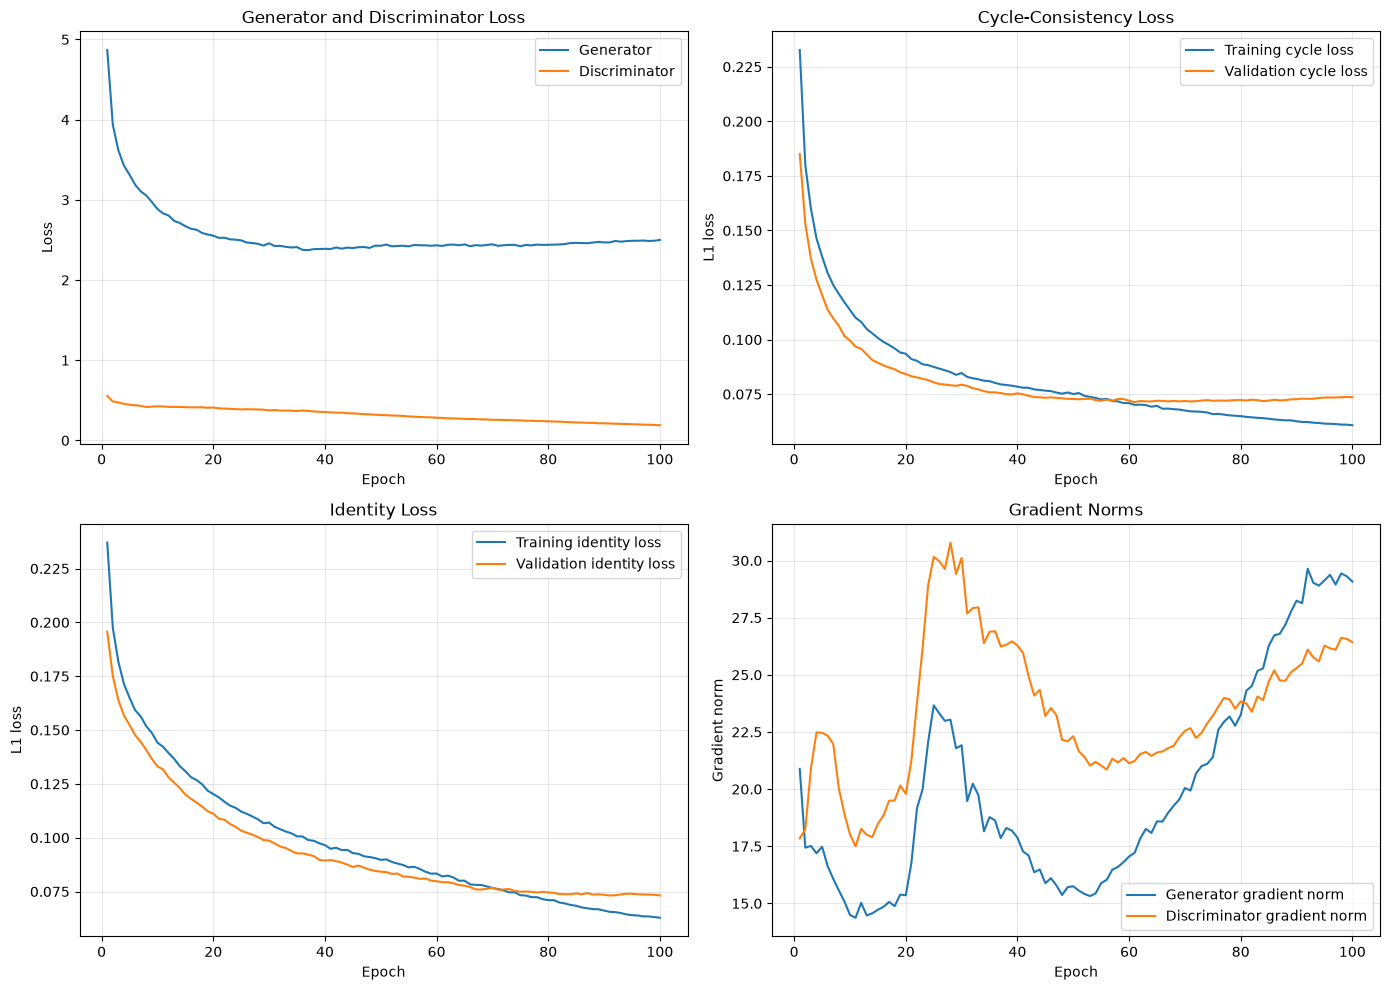

2026-10-02 09:15:26,512 - INFO - Training metrics saved to: /app/task3_gan_feature_matching_ema/results/training_history.csv
2026-10-02 09:15:26,513 - INFO - Training curves saved to: /app/task3_gan_feature_matching_ema/results/training_curves.png


Metrics saved to: /app/task3_gan_feature_matching_ema/results/training_history.csv
Curves saved to: /app/task3_gan_feature_matching_ema/results/training_curves.png


,epoch,learning_rate,train_generator_loss,train_discriminator_loss,train_cycle_a_loss,train_cycle_b_loss,train_identity_a_loss,train_identity_b_loss,train_feature_matching_loss,val_cycle_a_loss,...,val_identity_b_loss,generator_gradient_norm,discriminator_gradient_norm,nan_count,epoch_time_seconds,images_per_second,peak_memory_gb,train_cycle_mean,train_identity_mean,val_identity_mean
0,1,0.000200,4.867203,0.554279,0.238101,0.227199,0.237054,0.237066,0.013383,0.196252,...,0.193671,20.884874,17.841092,0,209.744971,68.853123,8.979430,0.232650,0.237060,0.195683
1,2,0.000200,3.935032,0.485526,0.182134,0.177658,0.196123,0.198704,0.012702,0.158647,...,0.171204,17.435384,18.247745,0,205.939309,69.927834,4.902264,0.179896,0.197413,0.175070
2,3,0.000200,3.614581,0.471649,0.161438,0.158649,0.179169,0.184150,0.012238,0.140583,...,0.162520,17.515546,20.888451,0,201.790722,71.490052,4.897476,0.160044,0.181660,0.163832
3,4,0.000200,3.425106,0.455771,0.149688,0.143104,0.169658,0.172985,0.012137,0.131147,...,0.154228,17.193371,22.479371,0,202.023538,71.397334,4.903358,0.146396,0.171322,0.156726
4,5,0.000200,3.312752,0.443965,0.142598,0.133620,0.164168,0.165765,0.012292,0.124657,...,0.149207,17.480039,22.464283,0,203.041859,71.076072,4.901264,0.138109,0.164967,0.152346
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,0.000020,2.489759,0.199832,0.064987,0.057886,0.071629,0.056152,0.009351,0.078788,...,0.068587,29.374945,26.160994,0,285.772062,50.052780,4.899178,0.061436,0.063891,0.073709
96,97,0.000016,2.491972,0.196766,0.064551,0.058080,0.071384,0.055533,0.009376,0.078775,...,0.068241,28.949796,26.096961,0,286.848751,49.851746,4.899918,0.061316,0.063459,0.073631
97,98,0.000012,2.487287,0.195153,0.064375,0.057751,0.071492,0.055369,0.009400,0.078661,...,0.068108,29.438594,26.616480,0,287.615585,49.860726,4.903831,0.061063,0.063431,0.073585
98,99,0.000008,2.489662,0.192561,0.064108,0.057961,0.070982,0.055293,0.009307,0.078835,...,0.067712,29.310444,26.575769,0,288.261928,49.618089,4.902607,0.061034,0.063138,0.073476


In [ ]:
history_df = save_training_results(
    training_history
)

display(history_df)

### Generating Evaluation images

In [ ]:
# ============================================================
# Step 13 - Generate evaluation images
# ============================================================

from torchvision.transforms.functional import to_pil_image


EVALUATION_IMAGE_COUNT = 30
EVALUATION_DIR = RESULTS_DIR / "evaluation_images"
EVALUATION_NUM_WORKERS = 0

# ------------------------------------------------------------
# 1. Create evaluation folders
# ------------------------------------------------------------

EVALUATION_FOLDERS = {
    "real_A": EVALUATION_DIR / "real_A",
    "fake_A": EVALUATION_DIR / "fake_A",
    "reconstructed_A": EVALUATION_DIR / "reconstructed_A",
    "real_B": EVALUATION_DIR / "real_B",
    "fake_B": EVALUATION_DIR / "fake_B",
    "reconstructed_B": EVALUATION_DIR / "reconstructed_B",
}

for folder in EVALUATION_FOLDERS.values():
    folder.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 2. Single-domain dataset
# ------------------------------------------------------------

class SingleDomainDataset(Dataset):
    def __init__(self, image_paths, transform):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        path = self.image_paths[index]

        image = Image.open(path).convert("RGB")
        image = self.transform(image)

        return {
            "image": image,
            "path": str(path),
        }


# ------------------------------------------------------------
# 3. Save normalized tensors as PNG images
# ------------------------------------------------------------

def save_tensor_image(image_tensor, output_path):
    image = image_tensor.detach().float().cpu()

    # Convert from [-1, 1] to [0, 1]
    image = image * 0.5 + 0.5
    image = image.clamp(0, 1)

    pil_image = to_pil_image(image)
    pil_image.save(output_path)


# ------------------------------------------------------------
# 4. Load generator weights from a checkpoint
# ------------------------------------------------------------

def load_generator_checkpoint(checkpoint_path):
    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False,
    )

    G_AB.load_state_dict(checkpoint["G_AB_state_dict"])
    G_BA.load_state_dict(checkpoint["G_BA_state_dict"])

    logger.info(
        f"Loaded generator checkpoint from: {checkpoint_path}"
    )


# ------------------------------------------------------------
# 5. Generate evaluation images
# ------------------------------------------------------------

def generate_evaluation_images():
    number_of_images = min(
        EVALUATION_IMAGE_COUNT,
        len(val_a_paths),
        len(val_b_paths),
    )

    evaluation_a_dataset = SingleDomainDataset(
        image_paths=val_a_paths[:number_of_images],
        transform=validation_transform,
    )

    evaluation_b_dataset = SingleDomainDataset(
        image_paths=val_b_paths[:number_of_images],
        transform=validation_transform,
    )

    evaluation_a_loader = DataLoader(
        evaluation_a_dataset,
        batch_size=1,
        shuffle=False,
        num_workers=EVALUATION_NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

    evaluation_b_loader = DataLoader(
        evaluation_b_dataset,
        batch_size=1,
        shuffle=False,
        num_workers=EVALUATION_NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

    G_AB.eval()
    G_BA.eval()

    # --------------------------------------------------------
    # Direction A -> B -> A
    # --------------------------------------------------------

    with torch.no_grad():
        for index, batch in enumerate(
            tqdm(
                evaluation_a_loader,
                desc="Generating photo-to-Monet images",
            )
        ):
            real_A = batch["image"].to(
                device,
                non_blocking=True,
            )

            with torch.autocast(
                device_type=device.type,
                dtype=AMP_DTYPE,
                enabled=USE_AMP,
            ):
                fake_B = G_AB(real_A)
                reconstructed_A = G_BA(fake_B)

            filename = f"{index:05d}.png"

            save_tensor_image(
                real_A[0],
                EVALUATION_FOLDERS["real_A"] / filename,
            )

            save_tensor_image(
                fake_B[0],
                EVALUATION_FOLDERS["fake_B"] / filename,
            )

            save_tensor_image(
                reconstructed_A[0],
                EVALUATION_FOLDERS[
                    "reconstructed_A"
                ] / filename,
            )

    # --------------------------------------------------------
    # Direction B -> A -> B
    # --------------------------------------------------------

    with torch.no_grad():
        for index, batch in enumerate(
            tqdm(
                evaluation_b_loader,
                desc="Generating Monet-to-photo images",
            )
        ):
            real_B = batch["image"].to(
                device,
                non_blocking=True,
            )

            with torch.autocast(
                device_type=device.type,
                dtype=AMP_DTYPE,
                enabled=USE_AMP,
            ):
                fake_A = G_BA(real_B)
                reconstructed_B = G_AB(fake_A)

            filename = f"{index:05d}.png"

            save_tensor_image(
                real_B[0],
                EVALUATION_FOLDERS["real_B"] / filename,
            )

            save_tensor_image(
                fake_A[0],
                EVALUATION_FOLDERS["fake_A"] / filename,
            )

            save_tensor_image(
                reconstructed_B[0],
                EVALUATION_FOLDERS[
                    "reconstructed_B"
                ] / filename,
            )

    G_AB.train()
    G_BA.train()

    logger.info(
        f"Generated {number_of_images} evaluation images "
        f"for each direction."
    )

    return number_of_images

In [ ]:
load_generator_checkpoint(
    BEST_CYCLE_CHECKPOINT_PATH
)

2026-10-02 09:15:27,571 - INFO - Loaded generator checkpoint from: /app/task3_gan_feature_matching_ema/checkpoints/best_cycle_checkpoint.pt


In [ ]:
# generating images

number_of_evaluation_images = (
    generate_evaluation_images()
)

print(
    "Evaluation images generated:",
    number_of_evaluation_images,
)

Generating Monet-to-photo images: 100%|██████████| 30/30 [00:03<00:00,  9.46it/s]
2026-10-02 09:15:34,233 - INFO - Generated 30 evaluation images for each direction.


Evaluation images generated: 30


### L1, LPIPS, and content similarity

Cycle L1: Compares the original image with its reconstruction. Lower is better.
LPIPS translation: Compares the original image with the translated image. Lower usually means more visual content was preserved.
LPIPS cycle: Compares the original with its reconstructed image. Lower is better.
Content cosine similarity: Compares high-level image features before and after translation. Higher is better.

In [ ]:
# %pip install -q lpips

In [ ]:

## L1, LPIPS, and content similarity


import json
import lpips
import torch.nn.functional as F

from torchvision.models import (
    inception_v3,
    Inception_V3_Weights,
)


METRIC_BATCH_SIZE = 4


# ------------------------------------------------------------
# 1. Dataset for matching saved images
# ------------------------------------------------------------

class EvaluationImageDataset(Dataset):
    def __init__(
        self,
        real_folder,
        fake_folder,
        reconstructed_folder,
    ):
        real_names = {
            path.name for path in real_folder.glob("*.png")
        }

        fake_names = {
            path.name for path in fake_folder.glob("*.png")
        }

        reconstructed_names = {
            path.name
            for path in reconstructed_folder.glob("*.png")
        }

        self.file_names = sorted(
            real_names
            & fake_names
            & reconstructed_names
        )

        if not self.file_names:
            raise ValueError(
                "No matching evaluation images were found."
            )

        self.real_folder = real_folder
        self.fake_folder = fake_folder
        self.reconstructed_folder = reconstructed_folder

        self.transform = transforms.ToTensor()

    def __len__(self):
        return len(self.file_names)

    def __getitem__(self, index):
        filename = self.file_names[index]

        real_image = Image.open(
            self.real_folder / filename
        ).convert("RGB")

        fake_image = Image.open(
            self.fake_folder / filename
        ).convert("RGB")

        reconstructed_image = Image.open(
            self.reconstructed_folder / filename
        ).convert("RGB")

        return {
            "real": self.transform(real_image),
            "fake": self.transform(fake_image),
            "reconstructed": self.transform(
                reconstructed_image
            ),
        }

In [ ]:
## creating metric models


## Create LPIPS and Inception models


lpips_model = lpips.LPIPS(
    net="alex",
    verbose=False,
).to(device)

lpips_model.eval()


inception_weights = Inception_V3_Weights.DEFAULT

content_model = inception_v3(
    weights=inception_weights,
)

# Return feature vectors instead of class predictions
content_model.fc = nn.Identity()

content_model = content_model.to(device)
content_model.eval()

/opt/conda/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

In [ ]:
## inception processing

# ------------------------------------------------------------
# 3. Prepare images for Inception V3
# ------------------------------------------------------------

def extract_content_features(images):
    # Images enter this function in [0, 1]
    images = F.interpolate(
        images,
        size=(342, 342),
        mode="bilinear",
        align_corners=False,
    )

    # Center crop from 342 to 299
    crop_start = (342 - 299) // 2

    images = images[
        :,
        :,
        crop_start:crop_start + 299,
        crop_start:crop_start + 299,
    ]

    mean = torch.tensor(
        [0.485, 0.456, 0.406],
        device=images.device,
    ).view(1, 3, 1, 1)

    std = torch.tensor(
        [0.229, 0.224, 0.225],
        device=images.device,
    ).view(1, 3, 1, 1)

    images = (images - mean) / std

    features = content_model(images)

    # Normalize each feature vector
    features = F.normalize(
        features,
        p=2,
        dim=1,
    )

    return features

In [ ]:
## calculatin metrics for one direction

def calculate_similarity_metrics(
    real_folder,
    fake_folder,
    reconstructed_folder,
):
    dataset = EvaluationImageDataset(
        real_folder=real_folder,
        fake_folder=fake_folder,
        reconstructed_folder=reconstructed_folder,
    )

    loader = DataLoader(
        dataset,
        batch_size=METRIC_BATCH_SIZE,
        shuffle=False,
        num_workers=EVALUATION_NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

    totals = {
        "cycle_l1": 0.0,
        "translation_lpips": 0.0,
        "cycle_lpips": 0.0,
        "content_cosine_similarity": 0.0,
    }

    image_count = 0

    with torch.no_grad():
        for batch in tqdm(
            loader,
            desc="Calculating similarity metrics",
        ):
            real_images = batch["real"].to(
                device,
                non_blocking=True,
            )

            fake_images = batch["fake"].to(
                device,
                non_blocking=True,
            )

            reconstructed_images = batch[
                "reconstructed"
            ].to(
                device,
                non_blocking=True,
            )

            current_batch_size = real_images.size(0)
            image_count += current_batch_size

            # Cycle-reconstruction L1 per image
            l1_per_image = (
                reconstructed_images - real_images
            ).abs().mean(dim=(1, 2, 3))

            # LPIPS expects values in [-1, 1]
            real_lpips = real_images * 2 - 1
            fake_lpips = fake_images * 2 - 1

            reconstructed_lpips = (
                reconstructed_images * 2 - 1
            )

            translation_lpips = lpips_model(
                real_lpips,
                fake_lpips,
            ).flatten()

            cycle_lpips = lpips_model(
                real_lpips,
                reconstructed_lpips,
            ).flatten()

            # High-level content similarity
            real_features = extract_content_features(
                real_images
            )

            fake_features = extract_content_features(
                fake_images
            )

            cosine_similarity = F.cosine_similarity(
                real_features,
                fake_features,
                dim=1,
            )

            totals["cycle_l1"] += (
                l1_per_image.sum().item()
            )

            totals["translation_lpips"] += (
                translation_lpips.sum().item()
            )

            totals["cycle_lpips"] += (
                cycle_lpips.sum().item()
            )

            totals["content_cosine_similarity"] += (
                cosine_similarity.sum().item()
            )

    return {
        name: value / image_count
        for name, value in totals.items()
    }

In [ ]:
## evaluating both directions


#  Calculate and save both directions


photo_to_monet_metrics = calculate_similarity_metrics(
    real_folder=EVALUATION_FOLDERS["real_A"],
    fake_folder=EVALUATION_FOLDERS["fake_B"],
    reconstructed_folder=EVALUATION_FOLDERS[
        "reconstructed_A"
    ],
)

monet_to_photo_metrics = calculate_similarity_metrics(
    real_folder=EVALUATION_FOLDERS["real_B"],
    fake_folder=EVALUATION_FOLDERS["fake_A"],
    reconstructed_folder=EVALUATION_FOLDERS[
        "reconstructed_B"
    ],
)

similarity_metrics = {
    "photo_to_monet": photo_to_monet_metrics,
    "monet_to_photo": monet_to_photo_metrics,
}

similarity_metrics_path = (
    RESULTS_DIR / "similarity_metrics.json"
)

with open(
    similarity_metrics_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        similarity_metrics,
        file,
        indent=4,
    )

print(
    pd.DataFrame(similarity_metrics).T.round(4)
)

logger.info(
    f"Similarity metrics saved to: "
    f"{similarity_metrics_path}"
)

Calculating similarity metrics: 100%|██████████| 8/8 [00:01<00:00,  6.85it/s]
2026-10-02 09:15:38,959 - INFO - Similarity metrics saved to: /app/task3_gan_feature_matching_ema/results/similarity_metrics.json


                cycle_l1  translation_lpips  cycle_lpips  \
photo_to_monet    0.0367             0.3967       0.1697   
monet_to_photo    0.0320             0.2792       0.1973   

                content_cosine_similarity  
photo_to_monet                     0.7722  
monet_to_photo                     0.8304  


### Calculating FID and KID

In [ ]:
%pip install -q torchmetrics torch-fidelity

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# ============================================================
## FID and KID
# ============================================================

from torchmetrics.image.fid import (
    FrechetInceptionDistance,
)

from torchmetrics.image.kid import (
    KernelInceptionDistance,
)


# ------------------------------------------------------------
# 1. Dataset containing real and generated image pairs
# ------------------------------------------------------------

class DistributionImageDataset(Dataset):
    def __init__(self, real_folder, fake_folder):
        real_names = {
            path.name for path in real_folder.glob("*.png")
        }

        fake_names = {
            path.name for path in fake_folder.glob("*.png")
        }

        self.file_names = sorted(
            real_names & fake_names
        )

        if len(self.file_names) < 2:
            raise ValueError(
                "At least two real and generated images "
                "are required."
            )

        self.real_folder = real_folder
        self.fake_folder = fake_folder
        self.transform = transforms.ToTensor()

    def __len__(self):
        return len(self.file_names)

    def __getitem__(self, index):
        filename = self.file_names[index]

        real_image = Image.open(
            self.real_folder / filename
        ).convert("RGB")

        fake_image = Image.open(
            self.fake_folder / filename
        ).convert("RGB")

        return {
            "real": self.transform(real_image),
            "fake": self.transform(fake_image),
        }

In [ ]:
##Calculate FID and KID for one direction

# ------------------------------------------------------------
## Directional FID and KID
# ------------------------------------------------------------

def calculate_fid_kid(real_folder, fake_folder):
    dataset = DistributionImageDataset(
        real_folder=real_folder,
        fake_folder=fake_folder,
    )

    loader = DataLoader(
        dataset,
        batch_size=METRIC_BATCH_SIZE,
        shuffle=False,
        num_workers=EVALUATION_NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

    number_of_images = len(dataset)

    # Use 20 images per KID subset when 30 are available
    kid_subset_size = min(
        20,
        number_of_images,
    )

    fid_metric = FrechetInceptionDistance(
        feature=2048,
        normalize=True,
    ).to(device)

    # Float64 improves the numerical stability of FID
    fid_metric.set_dtype(torch.float64)

    kid_metric = KernelInceptionDistance(
        feature=2048,
        subsets=10,
        subset_size=kid_subset_size,
        normalize=True,
    ).to(device)

    with torch.no_grad():
        for batch in tqdm(
            loader,
            desc="Calculating FID and KID",
        ):
            real_images = batch["real"].to(
                device,
                non_blocking=True,
            )

            fake_images = batch["fake"].to(
                device,
                non_blocking=True,
            )

            fid_metric.update(
                real_images,
                real=True,
            )

            fid_metric.update(
                fake_images,
                real=False,
            )

            kid_metric.update(
                real_images,
                real=True,
            )

            kid_metric.update(
                fake_images,
                real=False,
            )

    fid_score = fid_metric.compute()

    kid_mean, kid_std = kid_metric.compute()

    results = {
        "fid": float(fid_score.cpu()),
        "kid_mean": float(kid_mean.cpu()),
        "kid_std": float(kid_std.cpu()),
        "evaluation_images": number_of_images,
    }

    # Release the evaluation models from GPU memory
    del fid_metric
    del kid_metric

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return results

In [ ]:
# ------------------------------------------------------------
## Evaluate and save both directions
# ------------------------------------------------------------

photo_to_monet_distribution = calculate_fid_kid(
    real_folder=EVALUATION_FOLDERS["real_B"],
    fake_folder=EVALUATION_FOLDERS["fake_B"],
)

monet_to_photo_distribution = calculate_fid_kid(
    real_folder=EVALUATION_FOLDERS["real_A"],
    fake_folder=EVALUATION_FOLDERS["fake_A"],
)

distribution_metrics = {
    "photo_to_monet": photo_to_monet_distribution,
    "monet_to_photo": monet_to_photo_distribution,
}

distribution_metrics_path = (
    RESULTS_DIR / "distribution_metrics.json"
)

with open(
    distribution_metrics_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        distribution_metrics,
        file,
        indent=4,
    )

print(
    pd.DataFrame(distribution_metrics).T.round(4)
)

logger.info(
    f"FID and KID metrics saved to: "
    f"{distribution_metrics_path}"
)

/opt/conda/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)
Calculating FID and KID: 100%|██████████| 8/8 [00:01<00:00,  6.00it/s]
2026-10-02 09:15:51,555 - INFO - FID and KID metrics saved to: /app/task3_gan_feature_matching_ema/results/distribution_metrics.json


                     fid  kid_mean  kid_std  evaluation_images
photo_to_monet  181.2123    0.0036   0.0028               30.0
monet_to_photo  185.2984    0.0209   0.0055               30.0


In [ ]:
print("Validation photos:", len(val_a_paths))
print("Validation Monet images:", len(val_b_paths))
print("Requested evaluation images:", EVALUATION_IMAGE_COUNT)

for name, folder in EVALUATION_FOLDERS.items():
    print(name, len(list(folder.glob("*.png"))))

Validation photos: 703
Validation Monet images: 30
Requested evaluation images: 30
real_A 30
fake_A 30
reconstructed_A 30
real_B 30
fake_B 30
reconstructed_B 30


In [ ]:
EVALUATION_IMAGE_COUNT = 30

In [ ]:
## regenerate images

number_of_evaluation_images = (
    generate_evaluation_images()
)

print(
    "Evaluation images generated:",
    number_of_evaluation_images,
)

Generating Monet-to-photo images: 100%|██████████| 30/30 [00:03<00:00,  9.43it/s]
2026-10-02 09:15:57,929 - INFO - Generated 30 evaluation images for each direction.


Evaluation images generated: 30


In [ ]:
for name, folder in EVALUATION_FOLDERS.items():
    print(name, len(list(folder.glob("*.png"))))

real_A 30
fake_A 30
reconstructed_A 30
real_B 30
fake_B 30
reconstructed_B 30


In [ ]:
photo_to_monet_distribution = calculate_fid_kid(
    real_folder=EVALUATION_FOLDERS["real_B"],
    fake_folder=EVALUATION_FOLDERS["fake_B"],
)

monet_to_photo_distribution = calculate_fid_kid(
    real_folder=EVALUATION_FOLDERS["real_A"],
    fake_folder=EVALUATION_FOLDERS["fake_A"],
)

/opt/conda/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)
Calculating FID and KID: 100%|██████████| 8/8 [00:01<00:00,  5.57it/s]


In [ ]:
# ============================================================
# Generative precision and recall
# ============================================================


# ------------------------------------------------------------
# 1. Dataset for one image folder
# ------------------------------------------------------------

class ImageFolderDataset(Dataset):
    def __init__(self, folder):
        self.image_paths = sorted(
            folder.glob("*.png")
        )

        if not self.image_paths:
            raise ValueError(
                f"No PNG images found in: {folder}"
            )

        self.transform = transforms.ToTensor()

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image = Image.open(
            self.image_paths[index]
        ).convert("RGB")

        return self.transform(image)

In [ ]:
# ------------------------------------------------------------
# 2. Extract Inception feature vectors
# ------------------------------------------------------------

def extract_distribution_features(folder):
    dataset = ImageFolderDataset(folder)

    loader = DataLoader(
        dataset,
        batch_size=METRIC_BATCH_SIZE,
        shuffle=False,
        num_workers=EVALUATION_NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

    extracted_features = []

    with torch.no_grad():
        for images in loader:
            images = images.to(
                device,
                non_blocking=True,
            )

            # Resize to 342
            images = F.interpolate(
                images,
                size=(342, 342),
                mode="bilinear",
                align_corners=False,
            )

            # Center crop to 299
            crop_start = (342 - 299) // 2

            images = images[
                :,
                :,
                crop_start:crop_start + 299,
                crop_start:crop_start + 299,
            ]

            mean = torch.tensor(
                [0.485, 0.456, 0.406],
                device=device,
            ).view(1, 3, 1, 1)

            std = torch.tensor(
                [0.229, 0.224, 0.225],
                device=device,
            ).view(1, 3, 1, 1)

            images = (images - mean) / std

            features = content_model(images)

            extracted_features.append(
                features.float().cpu()
            )

    return torch.cat(
        extracted_features,
        dim=0,
    )

In [ ]:
# ------------------------------------------------------------
# 3. Feature-manifold precision and recall
# ------------------------------------------------------------

def calculate_manifold_radii(features, neighbor_count):
    distances = torch.cdist(
        features,
        features,
    )

    # Prevent each image from selecting itself
    distances.fill_diagonal_(float("inf"))

    radii = distances.kthvalue(
        neighbor_count,
        dim=1,
    ).values

    return radii


def calculate_generative_precision_recall(
    real_folder,
    fake_folder,
    neighbor_count=3,
):
    real_features = extract_distribution_features(
        real_folder
    )

    fake_features = extract_distribution_features(
        fake_folder
    )

    maximum_neighbors = min(
        len(real_features) - 1,
        len(fake_features) - 1,
    )

    neighbor_count = min(
        neighbor_count,
        maximum_neighbors,
    )

    if neighbor_count < 1:
        raise ValueError(
            "At least two real and generated images "
            "are required."
        )

    real_radii = calculate_manifold_radii(
        real_features,
        neighbor_count,
    )

    fake_radii = calculate_manifold_radii(
        fake_features,
        neighbor_count,
    )

    # Distance from every generated image to every real image
    fake_to_real_distances = torch.cdist(
        fake_features,
        real_features,
    )

    # Generated image is inside at least one real neighborhood
    fake_inside_real = (
        fake_to_real_distances
        <= real_radii.unsqueeze(0)
    ).any(dim=1)

    precision = (
        fake_inside_real.float().mean().item()
    )

    # Distance from every real image to every generated image
    real_to_fake_distances = torch.cdist(
        real_features,
        fake_features,
    )

    # Real image is inside at least one generated neighborhood
    real_inside_fake = (
        real_to_fake_distances
        <= fake_radii.unsqueeze(0)
    ).any(dim=1)

    recall = (
        real_inside_fake.float().mean().item()
    )

    return {
        "generative_precision": precision,
        "generative_recall": recall,
        "neighbor_count": neighbor_count,
        "real_images": len(real_features),
        "generated_images": len(fake_features),
    }

In [ ]:
# ------------------------------------------------------------
# 4. Calculate and save both directions
# ------------------------------------------------------------

photo_to_monet_pr = (
    calculate_generative_precision_recall(
        real_folder=EVALUATION_FOLDERS["real_B"],
        fake_folder=EVALUATION_FOLDERS["fake_B"],
    )
)

monet_to_photo_pr = (
    calculate_generative_precision_recall(
        real_folder=EVALUATION_FOLDERS["real_A"],
        fake_folder=EVALUATION_FOLDERS["fake_A"],
    )
)

precision_recall_metrics = {
    "photo_to_monet": photo_to_monet_pr,
    "monet_to_photo": monet_to_photo_pr,
}

precision_recall_path = (
    RESULTS_DIR / "precision_recall_metrics.json"
)

with open(
    precision_recall_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        precision_recall_metrics,
        file,
        indent=4,
    )

print(
    pd.DataFrame(
        precision_recall_metrics
    ).T.round(4)
)

logger.info(
    f"Precision and recall saved to: "
    f"{precision_recall_path}"
)

2026-10-02 09:16:16,719 - INFO - Precision and recall saved to: /app/task3_gan_feature_matching_ema/results/precision_recall_metrics.json


                generative_precision  generative_recall  neighbor_count  \
photo_to_monet                0.4000             0.6667             3.0   
monet_to_photo                0.6333             0.2333             3.0   

                real_images  generated_images  
photo_to_monet         30.0              30.0  
monet_to_photo         30.0              30.0  


### Human Audit

In [ ]:
# !pip install scikit-learn

In [ ]:
# ============================================================
# Step 17 - Human evaluation
# ============================================================

from sklearn.metrics import cohen_kappa_score


HUMAN_AUDIT_DIR = RESULTS_DIR / "human_audit"
HUMAN_AUDIT_DIR.mkdir(parents=True, exist_ok=True)

HUMAN_AUDIT_TEMPLATE = (
    HUMAN_AUDIT_DIR / "human_audit_scores.csv"
)


# ------------------------------------------------------------
# 1. Create the human-audit rating sheet
# ------------------------------------------------------------

def create_human_audit_template():
    rows = []

    # Use 15 images from each direction
    samples_per_direction = 15

    for index in range(samples_per_direction):
        filename = f"{index:05d}.png"

        rows.append({
            "sample_id": f"sample_{index + 1:02d}",
            "direction": "photo_to_monet",
            "source_image": str(
                EVALUATION_FOLDERS["real_A"] / filename
            ),
            "generated_image": str(
                EVALUATION_FOLDERS["fake_B"] / filename
            ),
            "rater_1_style": "",
            "rater_1_content": "",
            "rater_1_artifact_free": "",
            "rater_2_style": "",
            "rater_2_content": "",
            "rater_2_artifact_free": "",
        })

    for index in range(samples_per_direction):
        filename = f"{index:05d}.png"

        rows.append({
            "sample_id": (
                f"sample_{index + samples_per_direction + 1:02d}"
            ),
            "direction": "monet_to_photo",
            "source_image": str(
                EVALUATION_FOLDERS["real_B"] / filename
            ),
            "generated_image": str(
                EVALUATION_FOLDERS["fake_A"] / filename
            ),
            "rater_1_style": "",
            "rater_1_content": "",
            "rater_1_artifact_free": "",
            "rater_2_style": "",
            "rater_2_content": "",
            "rater_2_artifact_free": "",
        })

    audit_df = pd.DataFrame(rows)

    audit_df.to_csv(
        HUMAN_AUDIT_TEMPLATE,
        index=False,
    )

    logger.info(
        f"Human-audit template saved to: "
        f"{HUMAN_AUDIT_TEMPLATE}"
    )

    return audit_df

In [ ]:
# computing audit scores

# ------------------------------------------------------------
# 2. Calculate human-audit results
# ------------------------------------------------------------

def calculate_human_audit_results():
    audit_df = pd.read_csv(
        HUMAN_AUDIT_TEMPLATE
    )

    rating_columns = [
        "rater_1_style",
        "rater_1_content",
        "rater_1_artifact_free",
        "rater_2_style",
        "rater_2_content",
        "rater_2_artifact_free",
    ]

    # Check for missing ratings
    if audit_df[rating_columns].isna().any().any():
        raise ValueError(
            "The human-audit sheet contains missing ratings."
        )

    # Check that every score is between 1 and 5
    valid_scores = audit_df[rating_columns].apply(
        lambda column: column.between(1, 5)
    )

    if not valid_scores.all().all():
        raise ValueError(
            "Every human-audit score must be between 1 and 5."
        )

    criteria = [
        "style",
        "content",
        "artifact_free",
    ]

    results = {}

    all_rater_1_scores = []
    all_rater_2_scores = []

    for criterion in criteria:
        rater_1 = audit_df[
            f"rater_1_{criterion}"
        ].astype(int)

        rater_2 = audit_df[
            f"rater_2_{criterion}"
        ].astype(int)

        mean_score = (
            rater_1.mean() + rater_2.mean()
        ) / 2

        exact_agreement = (
            (rater_1 == rater_2).mean()
        )

        weighted_kappa = cohen_kappa_score(
            rater_1,
            rater_2,
            weights="quadratic",
        )

        results[criterion] = {
            "mean_score": float(mean_score),
            "exact_agreement": float(
                exact_agreement
            ),
            "weighted_cohens_kappa": float(
                weighted_kappa
            ),
        }

        all_rater_1_scores.extend(
            rater_1.tolist()
        )

        all_rater_2_scores.extend(
            rater_2.tolist()
        )

    # Overall score across all three criteria
    results["overall"] = {
        "mean_human_score": float(
            audit_df[rating_columns]
            .to_numpy()
            .mean()
        ),
        "exact_agreement": float(
            np.mean(
                np.array(all_rater_1_scores)
                == np.array(all_rater_2_scores)
            )
        ),
        "weighted_cohens_kappa": float(
            cohen_kappa_score(
                all_rater_1_scores,
                all_rater_2_scores,
                weights="quadratic",
            )
        ),
        "number_of_samples": len(audit_df),
        "number_of_raters": 2,
    }

    output_path = (
        HUMAN_AUDIT_DIR / "human_audit_results.json"
    )

    with open(
        output_path,
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            results,
            file,
            indent=4,
        )

    logger.info(
        f"Human-audit results saved to: {output_path}"
    )

    return results

In [ ]:
# human_audit_df = create_human_audit_template()

# display(human_audit_df.head())

In [ ]:
# human_audit_results = (
#     calculate_human_audit_results()
# )

# print(
#     json.dumps(
#         human_audit_results,
#         indent=4,
#     )
# )

In [ ]:
display(
    pd.DataFrame(training_history)[[
        "generator_gradient_norm",
        "discriminator_gradient_norm",
        "nan_count",
        "peak_memory_gb",
    ]]
)

,generator_gradient_norm,discriminator_gradient_norm,nan_count,peak_memory_gb
0,20.884874,17.841092,0,8.979430
1,17.435384,18.247745,0,4.902264
2,17.515546,20.888451,0,4.897476
3,17.193371,22.479371,0,4.903358
4,17.480039,22.464283,0,4.901264
...,...,...,...,...
95,29.374945,26.160994,0,4.899178
96,28.949796,26.096961,0,4.899918
97,29.438594,26.616480,0,4.903831
98,29.310444,26.575769,0,4.902607
